<a href="https://colab.research.google.com/github/naveen03-tech/CodSoft-Machine-Learning-internship/blob/main/Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
# Convert txt data to csv

In [62]:
import pandas as pd

# Read txt file
df = pd.read_csv('train_data.txt', sep='\t')



In [63]:
df

,"1 ::: Oscar et la dame rose (2009) ::: drama ::: Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue."
0,2 ::: Cupid (1997) ::: thriller ::: A brother ...
1,"3 ::: Young, Wild and Wonderful (1980) ::: adu..."
2,4 ::: The Secret Sin (1915) ::: drama ::: To h...
3,5 ::: The Unrecovered (2007) ::: drama ::: The...
4,6 ::: Quality Control (2011) ::: documentary :...
...,...
54208,"54210 ::: ""Bonino"" (1953) ::: comedy ::: This ..."
54209,54211 ::: Dead Girls Don't Cry (????) ::: horr...
54210,54212 ::: Ronald Goedemondt: Ze bestaan echt (...
54211,54213 ::: Make Your Own Bed (1944) ::: comedy ...


In [64]:
df.shape # give the size of the dataset

(54213, 1)

In [65]:
df.isnull()    # false means not a null values

,"1 ::: Oscar et la dame rose (2009) ::: drama ::: Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue."
0,False
1,False
2,False
3,False
4,False
...,...
54208,False
54209,False
54210,False
54211,False


In [66]:
# Naive Bayes

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("train_data.txt", sep='\t', header=None)

# Split the single column into separate fields
data = df[0].str.split(" ::: ", expand=True)

# Rename columns
data.columns = ["ID", "Title", "Genre", "Plot"]

# Keep only required columns
data = data[["Genre", "Plot"]]

# Remove missing values
data.dropna(inplace=True)

print("Dataset Shape:", data.shape)
print(data.head())

# Features and labels
X = data["Plot"]
y = data["Genre"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF + Naive Bayes Pipeline
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000
    )),
    ("clf", MultinomialNB())
])

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Example Prediction
sample_plot = """
A young wizard discovers magical powers and joins a school
where he battles dark forces threatening the world.
"""

predicted_genre = model.predict([sample_plot])[0]
print("\nPredicted Genre:", predicted_genre)

Dataset Shape: (54214, 2)
      Genre                                               Plot
0     drama  Listening in to a conversation between his doc...
1  thriller  A brother and sister with a past incestuous re...
2     adult  As the bus empties the students for their fiel...
3     drama  To help their unemployed father make ends meet...
4     drama  The film's title refers not only to the un-rec...

Accuracy: 0.5223646592271511

Classification Report:
              precision    recall  f1-score   support

      action       0.55      0.06      0.12       263
       adult       0.60      0.05      0.09       118
   adventure       0.75      0.04      0.07       155
   animation       0.00      0.00      0.00       100
   biography       0.00      0.00      0.00        53
      comedy       0.50      0.43      0.47      1490
       crime       0.00      0.00      0.00       101
 documentary       0.57      0.89      0.70      2619
       drama       0.46      0.82      0.59      2723
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
# LogisticRegression

In [69]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load data
df = pd.read_csv("train_data.txt", sep=" ::: ", engine="python",
                 names=["ID", "Title", "Genre", "Plot"])

# Remove missing values
df = df.dropna()

print(df.head())
print("Dataset Shape:", df.shape)

# Features and labels
X = df["Plot"]
y = df["Genre"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression
model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

print("Training model...")
model.fit(X_train_tfidf, y_train)

# Prediction
y_pred = model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

# Save model
joblib.dump(model, "genre_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

# Test
sample_plot = """
A detective investigates a mysterious murder in a small town.
As clues emerge, shocking secrets are uncovered.
"""

sample_vector = tfidf.transform([sample_plot])
prediction = model.predict(sample_vector)

print("Predicted Genre:", prediction[0])

   ID                             Title     Genre  \
0   1      Oscar et la dame rose (2009)     drama   
1   2                      Cupid (1997)  thriller   
2   3  Young, Wild and Wonderful (1980)     adult   
3   4             The Secret Sin (1915)     drama   
4   5            The Unrecovered (2007)     drama   

                                                Plot  
0  Listening in to a conversation between his doc...  
1  A brother and sister with a past incestuous re...  
2  As the bus empties the students for their fiel...  
3  To help their unemployed father make ends meet...  
4  The film's title refers not only to the un-rec...  
Dataset Shape: (54214, 4)
Training model...
Accuracy: 58.461680346767494
Model Saved Successfully!
Predicted Genre: thriller


Columns found: 4


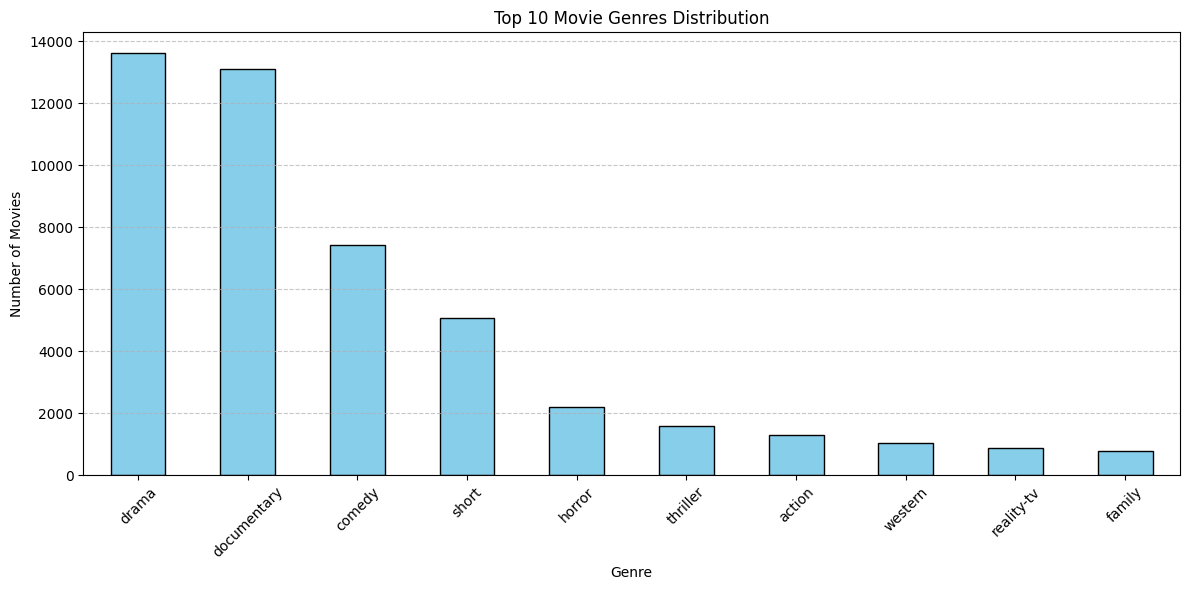

In [70]:
import pandas as pd # bar graph
import matplotlib.pyplot as plt

# Read TXT file
df = pd.read_csv("train_data.txt", sep='\t', header=None)

# Split the data into columns
data = df[0].str.split(" ::: ", expand=True)

# Check columns before renaming
print("Columns found:", len(data.columns))

# Rename columns
data.columns = ["ID", "Title", "Genre", "Plot"]

# Count genres
genre_counts = data["Genre"].value_counts().head(10)

# Create graph
plt.figure(figsize=(12,6))
genre_counts.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title("Top 10 Movie Genres Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

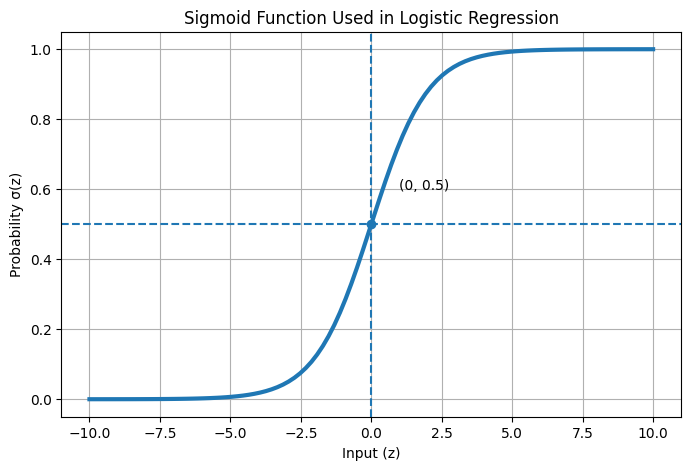

In [71]:
import numpy as np # sigmoid function it give output in probability(0 and 1)
import matplotlib.pyplot as plt

# Sigmoid Function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Generate values from -10 to 10
x = np.linspace(-10, 10, 100)
y = sigmoid(x)

# Plot graph
plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=3)

plt.title("Sigmoid Function Used in Logistic Regression")
plt.xlabel("Input (z)")
plt.ylabel("Probability σ(z)")

plt.axhline(y=0.5, linestyle='--')
plt.axvline(x=0, linestyle='--')

plt.scatter(0, 0.5)
plt.annotate("(0, 0.5)", xy=(0, 0.5), xytext=(1, 0.6))

plt.grid(True)
plt.show()

In [72]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    engine="python",
    header=None,
    names=["ID", "Title", "Genre", "Plot"]
)

# Features and Target
X = df["Plot"]
y = df["Genre"]

# Convert text to TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_tfidf = tfidf.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42
)

# -----------------------
# Naive Bayes
# -----------------------
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)

# -----------------------
# Logistic Regression
# -----------------------
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

# -----------------------
# Comparison
# -----------------------
print("\n===== MODEL COMPARISON =====")
print(f"Naive Bayes Accuracy       : {nb_accuracy:.4f}")
print(f"Logistic Regression Accuracy : {lr_accuracy:.4f}")

# Highlight Best Model
if nb_accuracy > lr_accuracy:
    print("\nBest Model: Naive Bayes")
    print(f"Highest Accuracy: {nb_accuracy:.4f}")
elif lr_accuracy > nb_accuracy:
    print("\n Best Model: Logistic Regression")
    print(f"Highest Accuracy: {lr_accuracy:.4f}")
else:
    print("\n Both models achieved the same accuracy.")


===== MODEL COMPARISON =====
Naive Bayes Accuracy       : 0.5225
Logistic Regression Accuracy : 0.5799

 Best Model: Logistic Regression
Highest Accuracy: 0.5799
